# 01 — Data Exploration & Baseline Model

**Dataset:** Zindi — *To Vaccinate or Not to Vaccinate?* (tweet sentiment: negative / neutral / positive)

This notebook covers:
1. Load the raw dataset
2. Class distribution
3. Tweet length distribution
4. Noisy data (URLs, mentions, hashtags, emojis)
5. Vocabulary characteristics
6. Clean the text + build the **locked train/val/test split** the rest of the group builds on
7. Model 1 baseline: TF-IDF + Logistic Regression


## Step 1 — Get the data


In [3]:
from google.colab import files
uploaded = files.upload ()  # select Train.csv

Saving Train.csv to Train (1).csv


## Step 2 — Load and inspect the raw structure

In [4]:
import pandas as pd

df = pd.read_csv("Train.csv")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (10001, 4)
Columns: ['tweet_id', 'safe_text', 'label', 'agreement']


,tweet_id,safe_text,label,agreement
0,CL1KWCMY,Me &amp; The Big Homie meanboy3000 #MEANBOY #M...,0.0,1.0
1,E3303EME,I'm 100% thinking of devoting my career to pro...,1.0,1.0
2,M4IVFSMS,"#whatcausesautism VACCINES, DO NOT VACCINATE Y...",-1.0,1.0
3,1DR6ROZ4,I mean if they immunize my kid with something ...,-1.0,1.0
4,J77ENIIE,Thanks to <user> Catch me performing at La Nui...,0.0,1.0


## Step 3 — Class distribution

The brief asks for this first: are the sentiment classes balanced? Raw labels are -1 (negative), 0 (neutral), 1 (positive).

label_name
neutral     4908
positive    4053
negative    1038
Name: count, dtype: int64
label_name
neutral     49.1
positive    40.5
negative    10.4
Name: count, dtype: float64


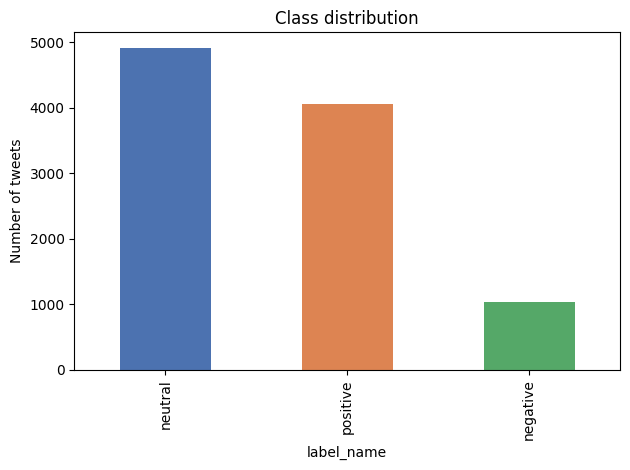

In [5]:
import matplotlib.pyplot as plt

label_names = {-1: "negative", 0: "neutral", 1: "positive"}
df["label_name"] = df["label"].map(label_names)

counts = df["label_name"].value_counts()
print(counts)
print((counts / len(df) * 100).round(1))

counts.plot(kind="bar", title="Class distribution", color=["#4C72B0", "#DD8452", "#55A868"])
plt.ylabel("Number of tweets")
plt.tight_layout()
plt.savefig("fig_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 4 — Tweet length distribution

Sequence length matters for every model downstream (max_len for tokenizers, padding, etc).

           char_len      word_len
count  10001.000000  10001.000000
mean      99.902810     16.264374
std       29.893888      5.348448
min        1.000000      1.000000
25%       79.000000     13.000000
50%      107.000000     17.000000
75%      122.000000     20.000000
max      153.000000     33.000000


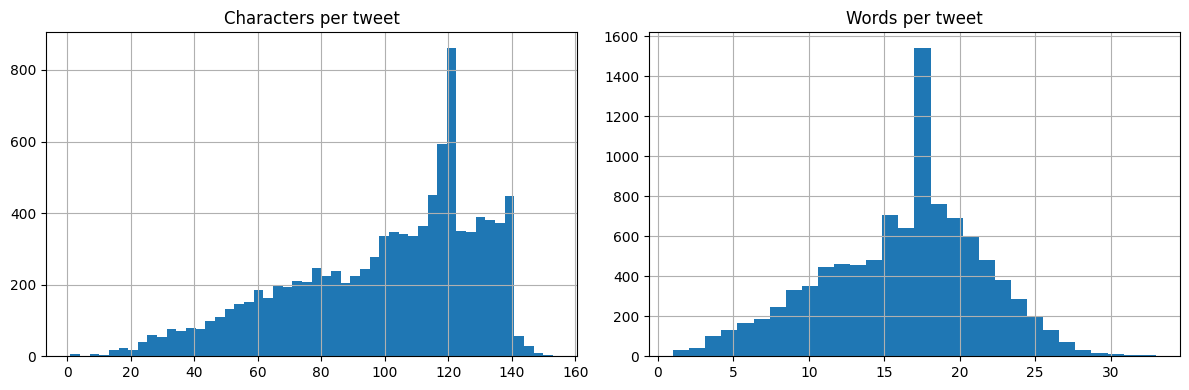

In [6]:
df["char_len"] = df["safe_text"].astype(str).str.len()
df["word_len"] = df["safe_text"].astype(str).str.split().str.len()

print(df[["char_len", "word_len"]].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["char_len"].hist(bins=50, ax=axes[0]); axes[0].set_title("Characters per tweet")
df["word_len"].hist(bins=30, ax=axes[1]); axes[1].set_title("Words per tweet")
plt.tight_layout()
plt.savefig("fig_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 5 — Noisy data: URLs, mentions, hashtags, emojis

The brief explicitly calls this out as something worth investigating for a text sequence task.

In [7]:
import re

df["has_url"] = df["safe_text"].astype(str).str.contains(r"http\S+|<url>", case=False, na=False)
df["has_mention"] = df["safe_text"].astype(str).str.contains(r"@\w+|<user>", na=False)
df["has_hashtag"] = df["safe_text"].astype(str).str.contains(r"#\w+", na=False)
df["has_emoji"] = df["safe_text"].astype(str).str.contains(
    r"[\U0001F300-\U0001FAFF\U00002700-\U000027BF]", na=False
)

for col in ["has_url", "has_mention", "has_hashtag", "has_emoji"]:
    print(col, round(df[col].mean() * 100, 1), "%")

print("\nSample messy tweets:")
df[df["has_emoji"] | df["has_hashtag"]][["safe_text"]].sample(5, random_state=42)

has_url 43.7 %
has_mention 40.4 %
has_hashtag 26.6 %
has_emoji 5.0 %

Sample messy tweets:


,safe_text
4050,"“<user> On average, people who complain live l..."
905,"Nancy Dirubbo says ""Think of immunizations as ..."
7827,Sen. Boxer wants all children at Head Start pr...
609,#EazyMix \n(Link in <user> bio) #ManyMenRecord...
732,Shocked when I walked into <user> practice &am...


## Step 6 — Vocabulary characteristics

Vocabulary size and how many words are rare (appear once) affects tokenization and OOV handling for every model.

In [8]:
from collections import Counter

all_words = " ".join(df["safe_text"].astype(str).str.lower()).split()
vocab = Counter(all_words)

print("Vocabulary size:", len(vocab))
print("Total tokens:", len(all_words))
print("Top 20 tokens:", vocab.most_common(20))

hapax = sum(1 for w, c in vocab.items() if c == 1)
print(f"Words appearing only once: {hapax} ({hapax/len(vocab)*100:.1f}% of vocab)")

# agreement column: fraction of annotators who agreed on this label — a data-quality signal
if "agreement" in df.columns:
    print("\nAgreement score summary:")
    print(df["agreement"].describe())
    low_agreement = (df["agreement"] < 0.6).mean()
    print(f"Tweets with agreement < 0.6: {low_agreement*100:.1f}%")

Vocabulary size: 22975
Total tokens: 162660
Top 20 tokens: [('<url>', 4612), ('<user>', 4517), ('the', 4040), ('to', 3581), ('measles', 2544), ('a', 2397), ('of', 2312), ('in', 2107), ('and', 1959), ('i', 1666), ('for', 1590), ('is', 1576), ('vaccine', 1173), ('you', 1108), ('your', 1065), ('are', 980), ('not', 978), ('on', 938), ('have', 933), ('that', 932)]
Words appearing only once: 15009 (65.3% of vocab)

Agreement score summary:
count    9999.000000
mean        0.854252
std         0.180707
min         0.333333
25%         0.666667
50%         1.000000
75%         1.000000
max         1.000000
Name: agreement, dtype: float64
Tweets with agreement < 0.6: 2.4%


## Step 7 — Clean the text and build the locked split

**This is the deliverable everyone else depends on.** From here on, nobody else re-cleans or re-splits the data — they load `train.csv` / `val.csv` / `test.csv` exactly as produced here.

- Labels remapped: negative → 0, neutral → 1, positive → 2 (needed for sklearn / PyTorch loss functions)
- Split: 70/15/15, stratified by label, `random_state=42` (fixed — never regenerate with a different seed)

In [10]:
import re
from sklearn.model_selection import train_test_split

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "<url>", text)
    text = re.sub(r"@\w+", "<user>", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"[^a-z0-9<>\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# --- diagnostic + cleanup ---
print(df["label"].unique())
print(df["label"].isna().sum(), "missing labels")
df = df.dropna(subset=["label"])
df["label"] = df["label"].astype(int)
# ----------------------------

df["text_clean"] = df["safe_text"].apply(clean_text)
df["text_raw"] = df["safe_text"]
df["label_final"] = df["label"].map({-1: 0, 0: 1, 1: 2})

final = df[["tweet_id", "text_raw", "text_clean", "label_final"]].rename(columns={"label_final": "label"})
print(final["label"].isna().sum(), "rows failed to map — should be 0")
final = final.dropna(subset=["label"])
final["label"] = final["label"].astype(int)

train_df, temp_df = train_test_split(final, test_size=0.30, stratify=final["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42)

print("train:", len(train_df), " val:", len(val_df), " test:", len(test_df))

train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)

from google.colab import files
files.download("train.csv")
files.download("val.csv")
files.download("test.csv")

[ 0.          1.         -1.                 nan  0.66666667]
1 missing labels
0 rows failed to map — should be 0
train: 7000  val: 1500  test: 1500


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Next:** upload `train.csv`, `val.csv`, `test.csv` into `data/processed/` in the group's shared repo. Everyone else loads from there — no exceptions.

## Step 8 — Model 1 baseline: TF-IDF + Logistic Regression

This is also the **template** the other three models should copy for how results get reported — same metrics, same row format, same confusion-matrix naming.

{'model_name': 'TFIDF_LogisticRegression', 'accuracy': 0.7273333333333334, 'macro_f1': 0.6640066450735064, 'precision_macro': 0.6538896662504667, 'recall_macro': 0.6921631376609775, 'train_time_s': 1.52, 'notes': 'TF-IDF unigrams+bigrams, 10k features, class_weight=balanced'}


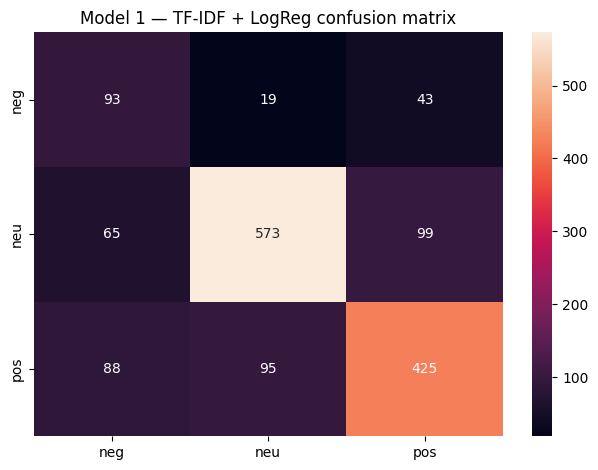

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import time
import seaborn as sns

vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(train_df["text_clean"])
X_val = vectorizer.transform(val_df["text_clean"])
y_train, y_val = train_df["label"], val_df["label"]

start = time.time()
clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(X_train, y_train)
train_time = time.time() - start

preds = clf.predict(X_val)

row = {
    "model_name": "TFIDF_LogisticRegression",
    "accuracy": accuracy_score(y_val, preds),
    "macro_f1": f1_score(y_val, preds, average="macro"),
    "precision_macro": precision_score(y_val, preds, average="macro"),
    "recall_macro": recall_score(y_val, preds, average="macro"),
    "train_time_s": round(train_time, 2),
    "notes": "TF-IDF unigrams+bigrams, 10k features, class_weight=balanced",
}
print(row)

cm = confusion_matrix(y_val, preds)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["neg","neu","pos"], yticklabels=["neg","neu","pos"])
plt.title("Model 1 — TF-IDF + LogReg confusion matrix")
plt.tight_layout()
plt.savefig("cm_model1.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame([row]).to_csv("model1_result_row.csv", index=False)
files.download("model1_result_row.csv")
files.download("cm_model1.png")